
# Importações

Obs: Converter em um arquivo .py para executar.

In [3]:
import argparse

import os
import sys
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error as mape, root_mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler

from pyESN import ESN
from shap.plots import colors
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

MODELOS = ["ESN", "MLP", "RF", "XGBoost"]
OTIMIZADORES = ["PSO", "SA"]
N_ITER = 15
N_SOLUCOES = 15
SEED = 100
SEEDS = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
HORIZONTE = 6


def reset_seed(rnd_seed=SEED):
    os.environ['PYTHONHASHSEED'] = '0'
    random.seed(rnd_seed)
    np.random.seed(rnd_seed)


def calcular_rrmse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    rmse = root_mean_squared_error(y_true, y_pred)

    mean_y_true = np.mean(y_true)

    rrmse = rmse / mean_y_true
    return rrmse


reset_seed()

# Carregar Datasets

In [4]:
df = pd.read_csv("./dados/dados_tratados.csv", sep=';', decimal='.')
df

,CONSUMO,DATA,TEMP_MIN_MÉD_MENS,TEMP_MÉD_MIN_MENS,TEMP_MÉD_MÉD_MENS,TEMP_MÉD_MAX_MENS,TEMP_MÉD_ACC_MENS,TEMP_MAX_MÉD_MENS,PRECIPITAÇÃO_MÉD_MENS,TEMP_MIN_MIN_MENS,...,CURSOS_GRAD_VESPERTINO,CURSOS_GRAD_NOTURNO,CURSOS_POS,FÉRIAS,FERIADO,COVID,GREVE,CAMPUS,REGIÃO,ORDEM
0,11400.0,2015-02-28,18,22,25,27,692,33,4,18,...,0,1,1,0,3,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,1
1,18427.0,2015-03-31,12,19,24,26,729,32,2,12,...,0,2,1,0,0,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,2
2,14274.0,2015-04-30,13,19,21,24,640,29,6,13,...,0,2,1,0,1,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,3
3,11987.0,2015-05-31,7,11,18,23,557,28,9,7,...,0,2,1,0,0,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,4
4,9006.0,2015-06-30,4,10,18,22,542,29,1,4,...,0,2,1,0,1,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2378,5640.0,2024-06-30,0,8,17,20,499,26,1,0,...,1,1,0,0,0,0,30,UNIÃO DA VITÓRIA,REGIÃO SUL,81
2379,11687.0,2024-07-31,1,9,13,18,413,25,6,1,...,1,1,0,12,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,82
2380,11129.0,2024-08-31,-3,7,15,21,468,31,1,-3,...,1,1,0,0,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,83
2381,9690.0,2024-09-30,10,13,20,24,591,34,3,10,...,1,1,0,0,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,84


## Normalização

In [5]:
# Repete a normalização para obtermos so scalers correspondentes
scalers = {}
dataframes = []

for campus, dados in df.groupby("CAMPUS"):
    scaler = MinMaxScaler()
    dados[["CONSUMO"]] = scaler.fit_transform(dados[["CONSUMO"]])

    scalers[campus] = scaler
    dataframes.append(dados)

df = pd.concat(dataframes, ignore_index=True)

df

,CONSUMO,DATA,TEMP_MIN_MÉD_MENS,TEMP_MÉD_MIN_MENS,TEMP_MÉD_MÉD_MENS,TEMP_MÉD_MAX_MENS,TEMP_MÉD_ACC_MENS,TEMP_MAX_MÉD_MENS,PRECIPITAÇÃO_MÉD_MENS,TEMP_MIN_MIN_MENS,...,CURSOS_GRAD_VESPERTINO,CURSOS_GRAD_NOTURNO,CURSOS_POS,FÉRIAS,FERIADO,COVID,GREVE,CAMPUS,REGIÃO,ORDEM
0,0.502037,2015-02-28,18,22,25,27,692,33,4,18,...,0,1,1,0,3,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,1
1,0.846886,2015-03-31,12,19,24,26,729,32,2,12,...,0,2,1,0,0,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,2
2,0.643078,2015-04-30,13,19,21,24,640,29,6,13,...,0,2,1,0,1,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,3
3,0.530844,2015-05-31,7,11,18,23,557,28,9,7,...,0,2,1,0,0,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,4
4,0.384551,2015-06-30,4,10,18,22,542,29,1,4,...,0,2,1,0,1,0,0,ASSIS CHATEAUBRIAND,REGIÃO OESTE,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2378,0.359224,2024-06-30,0,8,17,20,499,26,1,0,...,1,1,0,0,0,0,30,UNIÃO DA VITÓRIA,REGIÃO SUL,81
2379,1.000000,2024-07-31,1,9,13,18,413,25,6,1,...,1,1,0,12,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,82
2380,0.940871,2024-08-31,-3,7,15,21,468,31,1,-3,...,1,1,0,0,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,83
2381,0.788386,2024-09-30,10,13,20,24,591,34,3,10,...,1,1,0,0,0,0,0,UNIÃO DA VITÓRIA,REGIÃO SUL,84


## Criação dos Lags

In [6]:
dataframes = []

for campus, dados in df.sort_values("DATA").groupby("CAMPUS"):
    lags = {f'LAG_{i:02d}': dados['CONSUMO'].shift(i) for i in range(1, 12 + 1)}
    dados = pd.concat([dados, pd.DataFrame(lags)], axis=1)
    dados.dropna(inplace=True)
    dados["ORDEM"] = range(1, len(dados) + 1)
    dataframes.append(dados)

df = pd.concat(dataframes, ignore_index=True)
df

,CONSUMO,DATA,TEMP_MIN_MÉD_MENS,TEMP_MÉD_MIN_MENS,TEMP_MÉD_MÉD_MENS,TEMP_MÉD_MAX_MENS,TEMP_MÉD_ACC_MENS,TEMP_MAX_MÉD_MENS,PRECIPITAÇÃO_MÉD_MENS,TEMP_MIN_MIN_MENS,...,LAG_03,LAG_04,LAG_05,LAG_06,LAG_07,LAG_08,LAG_09,LAG_10,LAG_11,LAG_12
0,0.615105,2016-02-29,19,22,25,28,734,33,4,19,...,0.570938,0.553762,0.386907,0.331354,0.302547,0.384551,0.530844,0.643078,0.846886,0.502037
1,0.711047,2016-03-31,12,17,22,28,685,32,3,12,...,0.580507,0.570938,0.553762,0.386907,0.331354,0.302547,0.384551,0.530844,0.643078,0.846886
2,0.633361,2016-04-30,4,9,23,28,702,33,2,4,...,0.424204,0.580507,0.570938,0.553762,0.386907,0.331354,0.302547,0.384551,0.530844,0.643078
3,0.406291,2016-05-31,4,11,16,22,490,27,9,4,...,0.615105,0.424204,0.580507,0.570938,0.553762,0.386907,0.331354,0.302547,0.384551,0.530844
4,0.362467,2016-06-30,-1,7,14,20,408,27,3,-1,...,0.711047,0.615105,0.424204,0.580507,0.570938,0.553762,0.386907,0.331354,0.302547,0.384551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2090,0.359224,2024-06-30,0,8,17,20,499,26,1,0,...,0.990145,0.803327,0.457985,0.822613,0.794744,0.559818,0.747059,0.839038,0.553248,0.743880
2091,1.000000,2024-07-31,1,9,13,18,413,25,6,1,...,0.680301,0.990145,0.803327,0.457985,0.822613,0.794744,0.559818,0.747059,0.839038,0.553248
2092,0.940871,2024-08-31,-3,7,15,21,468,31,1,-3,...,0.352866,0.680301,0.990145,0.803327,0.457985,0.822613,0.794744,0.559818,0.747059,0.839038
2093,0.788386,2024-09-30,10,13,20,24,591,34,3,10,...,0.359224,0.352866,0.680301,0.990145,0.803327,0.457985,0.822613,0.794744,0.559818,0.747059


## Melhores Features

In [7]:
df_features = pd.read_csv("./resultados/features/fitness_features_regressao.csv", sep=";", decimal=".")

df_features = df_features.sort_values("RRMSE").head(1).reset_index(drop=True)
df_features = pd.DataFrame(
    columns=str(df_features.iloc[0]["FEATURES"]).replace("(", '').replace(")", '').replace("'", "").split(", "))

df_features = df_features.columns

df_features

Index(['TEMP_MÉD_ACC_MENS', 'TEMP_MIN_MAX_MENS', 'TEMP_MIN_ACC_MENS',
       'PRECIPITAÇÃO_MIN_MENS', 'TEMP_MAX_ACC_MENS', 'PRECIPITAÇÃO_MAX_MENS',
       'DIA_DA_SEMANA_sex', 'MÊS_abr', 'MÊS_jul', 'MÊS_mai', 'MÊS_mar',
       'ANO_2024', 'ANO_2015', 'ANO_2017', 'ANO_2020', 'ANO_2014',
       'CAMPUS_ARAPONGAS', 'CAMPUS_CAMPO LARGO', 'CAMPUS_COLOMBO',
       'CAMPUS_LONDRINA - CENTRO', 'CAMPUS_LONDRINA - NORTE',
       'CAMPUS_PARANAVAÍ', 'CAMPUS_QUEDAS DO IGUAÇU', 'CURSOS_GRAD_MATUTINO',
       'CURSOS_GRAD_VESPERTINO', 'FÉRIAS', 'COVID', 'ORDEM', 'LAG_01',
       'LAG_02', 'LAG_03', 'LAG_04', 'LAG_05', 'LAG_06', 'LAG_08', 'LAG_11',
       'LAG_12'],
      dtype='object')

## Melhores Parâmetros

In [8]:
def get_modelo(nome):
    if nome == "ESN":
        return ESN(n_inputs=df_features.shape[0],
                   n_outputs=1,
                   n_reservoir=int(best["ESN"]["Reservoirs"]),
                   sparsity=best["ESN"]["Sparsity"],
                   spectral_radius=best["ESN"]["Spectral Radius"],
                   random_state=SEED)

    if nome == "MLP":
        mlp = MLPRegressor(hidden_layer_sizes=(int(best["MLP"]["Hidden Layers"]),),
                           activation=best["MLP"]["Activation"],
                           alpha=best["MLP"]["Alpha"],
                           random_state=SEED)
        return mlp

    if nome == "RF":
        return RandomForestRegressor(random_state=SEED,
                                n_estimators=int(best["RF"]["N_estimators"]),
                                max_depth=int(best["RF"]["Max_depth"]),
                                min_samples_split=int(best["RF"]["Min_samples_split"]),
                                min_samples_leaf=int(best["RF"]["Min_samples_leaf"]))

    if nome == "XGBoost":
        updater = "coord_descent" if best["XGBoost"]["Booster"] == "gblinear" else None
        return XGBRegressor(random_state=SEED,
                            n_estimators=int(best["XGBoost"]["N_estimators"]),
                            max_depth=int(best["XGBoost"]["Max_depth"]),
                            booster=best["XGBoost"]["Booster"],
                            reg_lambda=best["XGBoost"]["Lambda"],
                            reg_alpha=best["XGBoost"]["Alpha"],
                            updater=updater)


best = {}
for modelo in MODELOS:
    df_aux = pd.DataFrame()
    for optimizer in OTIMIZADORES:
        for seed in SEEDS:
            try:
                new_df = pd.read_csv(f'resultados/otimização - regressão/{optimizer}-{modelo} SEED {seed}.csv',
                                         sep=";",
                                         decimal=".",
                                         header=0)
                df_aux = pd.concat([df_aux, new_df], axis=0)
            except Exception as e:
                continue
    df_aux = df_aux.sort_values(by=["Fitness"])
    df_aux[df_aux.isnull()] = None
    best[f"{modelo}"] = df_aux[:1].iloc[0].to_dict()

print(best)

{'ESN': {'Unnamed: 0': 0.0, 'Reservoirs': 229.0, 'Sparsity': 0.126, 'Spectral Radius': 0.404, 'Fitness': -0.09375}, 'LSTM': {'Unnamed: 0': 160, 'Units': 368, 'Epochs': 178, 'Batch Size': 30, 'Activation': 'sigmoid', 'Fitness': 0.34329495}, 'MLP': {'Unnamed: 0': 0, 'Hidden Layers': 229, 'Alpha': 0.85, 'Activation': 'identity', 'Fitness': -0.0833333333333333}, 'RF': {'Unnamed: 0': 1.0, 'N_estimators': 229.0, 'Max_depth': 352.0, 'Min_samples_split': 8.0, 'Min_samples_leaf': 27.0, 'Fitness': -0.0729166666666666}, 'XGBoost': {'Unnamed: 0': 0, 'N_estimators': 90, 'Max_depth': 299, 'Booster': 'gbtree', 'Lambda': 0.1823, 'Alpha': 0.7435, 'Fitness': -0.1770833333333333}}


# Treino e Teste

In [ ]:
def treino(previsor, dataframe_treino, features):
    x_treino = dataframe_treino.drop(columns=["CONSUMO"])[features].astype(np.float32).to_numpy()
    y_treino = dataframe_treino["CONSUMO"].astype(np.float32).to_numpy()

    previsor.fit(x_treino, y_treino)
    return previsor


def teste(previsor, dataframe_treino, dataframe_teste, features, horizonte):
    dataframe_treino = dataframe_treino.sort_values("DATA")
    dataframe_treino = dataframe_treino.set_index("DATA")

    dataframe_teste = dataframe_teste.sort_values("DATA")
    dataframe_teste = dataframe_teste.set_index("DATA")

    x_teste = dataframe_teste.drop(columns=["CONSUMO"])[features].astype(np.float32)

    dataframe_treino = dataframe_treino[np.append(features, "CONSUMO")].astype(np.float32)

    prevs = []

    for i_test in range(horizonte):
        row = x_teste.iloc[[i_test]].copy()

        # Acrescenta as variáveis de teste correspondentes à iteração atual
        dataframe_treino = pd.concat([dataframe_treino, row], axis=0)

        # Recalcula os lags conforme os valores previstos pelo modelo
        # Na primeira iteração os lags são os valores reais
        # TODO VERIFICAR SE ESTÁ CORRETA A PREVISÃO RECURSIVA
        for lag in range(1, 12 + 1):
            if 'LAG_' + "{:02d}".format(lag) in x_teste.columns:
                row[f'LAG_' + '{:02d}'.format(lag)] = dataframe_treino["CONSUMO"].shift(lag)
                dataframe_treino[f'LAG_' + '{:02d}'.format(lag)] = dataframe_treino["CONSUMO"].shift(lag)

        # Ajusta a saída dependendo do modelo
        if (isinstance(previsor, RandomForestRegressor)
                or isinstance(previsor, XGBRegressor)
                or isinstance(previsor, MLPRegressor)):  # Se for o RF, XGBoost ou MLP
            pred = previsor.predict(row[features].to_numpy().reshape(1, -1))
        elif isinstance(previsor, ESN):  # Se for o ESN
            pred = previsor.predict(row[features].to_numpy().reshape(1, -1))[0]
        else:
            pred = previsor.predict(row[features].to_numpy().reshape(1, -1), verbose=0)[0]

        pred = pred[0]
        # Atualiza o valor previsto na linha atual
        row["CONSUMO"] = pred
        # Adiciona o valor previsto à lista de previsões
        prevs.append(pred)
        # Atualiza o dataframe com a linha atual, para ser usada na próxima iteração
        dataframe_treino.update(row)
    return pd.DataFrame({"CONSUMO PREVISTO": prevs}, index=dataframe_teste.index)

## Divisão dos Dados


In [ ]:
dataframes_treino = []
dataframes_teste = []

for campus, dados in df.sort_values('DATA').groupby("CAMPUS"):
    dados["CAMPUS"] = campus

    dados_treino, dados_teste = train_test_split(dados, test_size=HORIZONTE, random_state=SEED, shuffle=False)

    dataframes_treino.append(dados_treino)
    dataframes_teste.append(dados_teste)

df_treino = pd.DataFrame(pd.concat(dataframes_treino, ignore_index=True))
df_teste = pd.DataFrame(pd.concat(dataframes_teste, ignore_index=True))

CAMPUS = df_teste["CAMPUS"].unique().tolist()

parser = argparse.ArgumentParser(description="Otimização de modelos.")
parser.add_argument('--campus', help="Campus.", default=CAMPUS[0])
parser.add_argument('--experimento', help="0 - Treinamento Conjunto | 1 - Treinamento Individual", default="0")
parser.add_argument('--continua', help="Continua a previsão com os demais campus e experimentos.", default="1")
args = parser.parse_args()


## Treino com todos os campi

In [ ]:

if args.experimento == "0":
    print(f"Executando a previsão em conjunto do campus {args.campus}.")
    for campus, dados_teste in df_teste[df_teste["CAMPUS"] == args.campus].groupby("CAMPUS"):
        df_previsoes = pd.DataFrame(columns=MODELOS, index=dados_teste["DATA"])

        # Reordena o dataframe de treino para que o campus atual seja o último
        dados_treino = pd.concat(
            [df_treino[df_treino["CAMPUS"] != campus], df_treino[df_treino["CAMPUS"] == campus]]).reset_index()

        for nome_modelo in MODELOS:
            # Treina o modelo com os dados de todos os campi
            modelo = treino(get_modelo(nome_modelo), dados_treino, df_features)

            # Testa o modelo com os dados do campus atual
            previsoes = teste(modelo, dados_treino, dados_teste, df_features, HORIZONTE)
            df_previsoes[[nome_modelo]] = scalers[campus].inverse_transform(previsoes[["CONSUMO PREVISTO"]])

        df_previsoes.to_csv(f"resultados/regressão - conjunto/{HORIZONTE}M - {campus}.csv", sep=";", decimal=".",
                            index=True)

        if args.continua == "1":
            indice_campus = CAMPUS.index(args.campus) if args.campus is not None else 0
            if indice_campus < len(CAMPUS) - 1:
                os.execv(sys.executable,
                         [sys.executable, *sys.argv,
                          '--campus', str(CAMPUS[indice_campus + 1]),
                          '--experimento', "0",
                          '--continua', "1"])
            else:
                os.execv(sys.executable,
                         [sys.executable, *sys.argv,
                          '--campus', str(CAMPUS[0]),
                          '--experimento', "1",
                          '--continua', "1"])




## Treino com campi individuais

In [ ]:

if args.experimento == "1":
    print(f"Executando a previsão individual do campus {args.campus}.")
    for campus, dados_teste in df_teste[df_teste["CAMPUS"] == args.campus].groupby("CAMPUS"):
        df_previsoes = pd.DataFrame(columns=MODELOS, index=dados_teste["DATA"])

        for nome_modelo in MODELOS:
            # Treina o modelo com os dados do campus atual
            dados_treino = df_treino[df_treino["CAMPUS"] == campus]
            modelo = treino(get_modelo(nome_modelo), dados_treino, df_features)

            # Testa o modelo com os dados do campus atual
            previsoes = teste(modelo, dados_treino, dados_teste, df_features, HORIZONTE)
            df_previsoes[[nome_modelo]] = scalers[campus].inverse_transform(previsoes[["CONSUMO PREVISTO"]])

        df_previsoes.to_csv(f"resultados/regressão - individual/{HORIZONTE}M - {campus}.csv", sep=";", decimal=".",
                            index=True)

        if args.continua == "1":
            indice_campus = CAMPUS.index(args.campus) if args.campus is not None else 0
            if indice_campus < len(CAMPUS) - 1:
                os.execv(sys.executable,
                         [sys.executable, *sys.argv,
                          '--campus', str(CAMPUS[indice_campus + 1]),
                          '--experimento', "1",
                          '--continua', "1"])


# Análise dos Resultados

In [ ]:
def ts_comparacao(campus, valor_real, valores_previstos, erros):
    valor_real = valor_real.tail(HORIZONTE)
    plt.figure(figsize=(12, 4.5))
    plt.rcParams['xtick.labelsize'] = 13
    plt.rcParams['ytick.labelsize'] = 14
    plt.rcParams.update({'font.size': 12})
    plt.rcParams['axes.prop_cycle'] = plt.cycler(
        color=["blue", "green", "darkgoldenrod", colors.red_rgb, "purple", "cyan", "slategrey", "coral"])

    for nome_modelo in valores_previstos.columns:
        plt.plot(valores_previstos[nome_modelo],
                 label=f"{nome_modelo} - {campus} (RRMSE: {erros.loc[nome_modelo]["RRMSE"]:.2%})")

    plt.plot(valor_real["CONSUMO"], label=f"CONSUMO REAL - {campus}", color="black")

    plt.xlabel('Mês')
    plt.ylabel('Consumo (KWh)')

    ax = plt.gca()
    ax.set_facecolor('white')

    plt.grid(True, color='grey', linestyle="--", linewidth=0.5)
    plt.legend(facecolor='white')

    return plt


def medidas_erro(valor_real, valores_previstos):
    df_desempenho = pd.DataFrame(columns=["MAPE", "RRMSE"], index=valores_previstos.columns)

    for nome_modelo in valores_previstos.columns:
        df_desempenho.loc[nome_modelo] = [
            mape(valor_real["CONSUMO"].tail(HORIZONTE), valores_previstos[nome_modelo].tail(HORIZONTE)),
            calcular_rrmse(valor_real["CONSUMO"].tail(HORIZONTE), valores_previstos[nome_modelo].tail(HORIZONTE))
        ]

    return df_desempenho


## Campi em conjunto

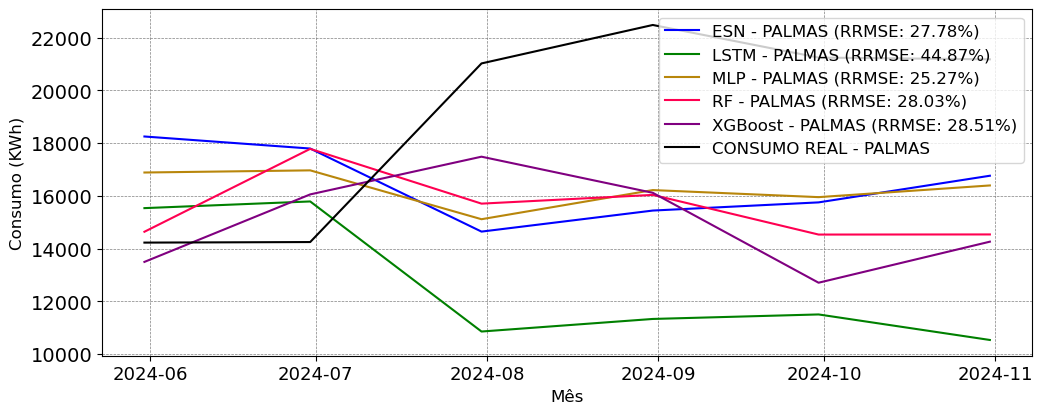

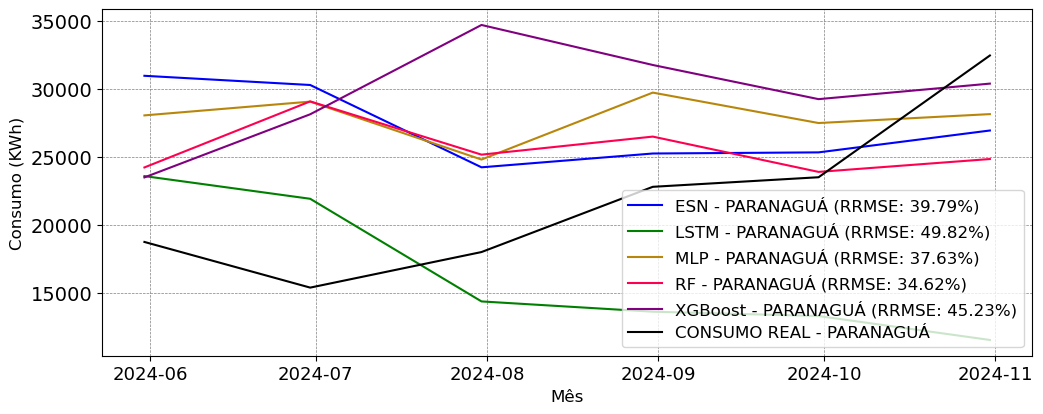

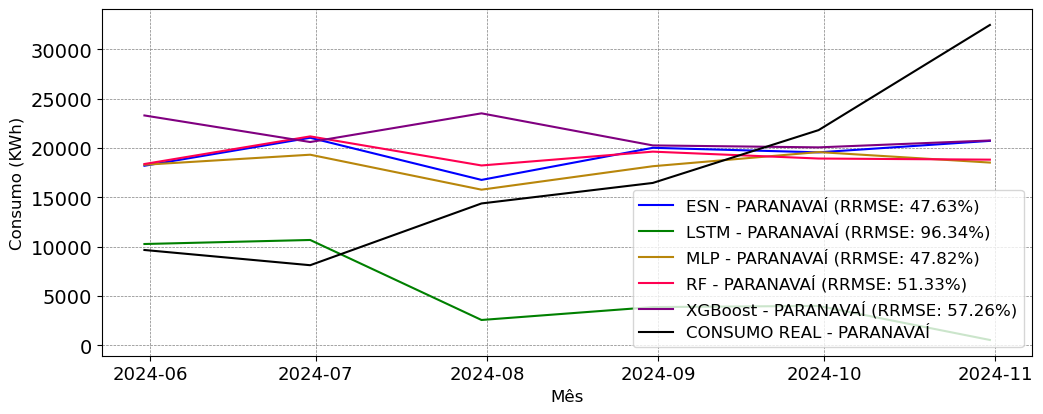

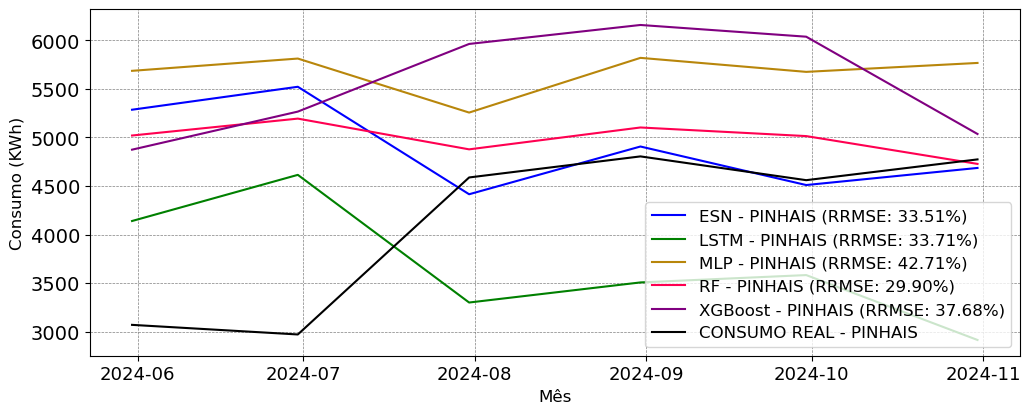

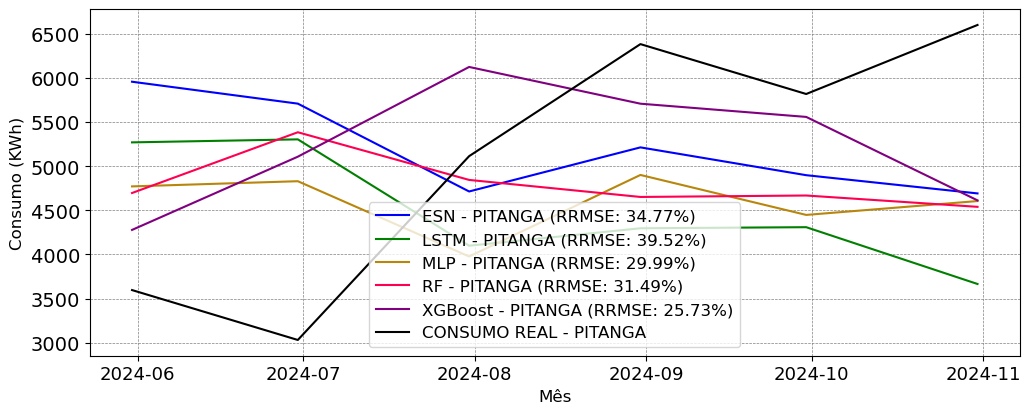

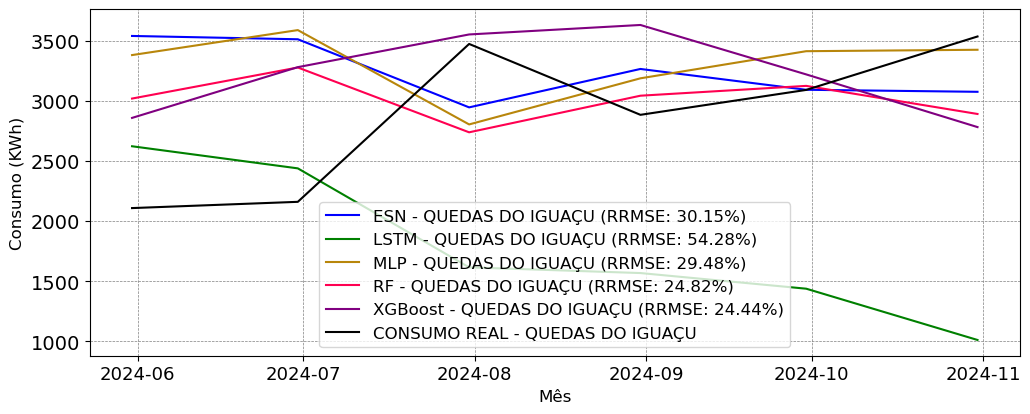

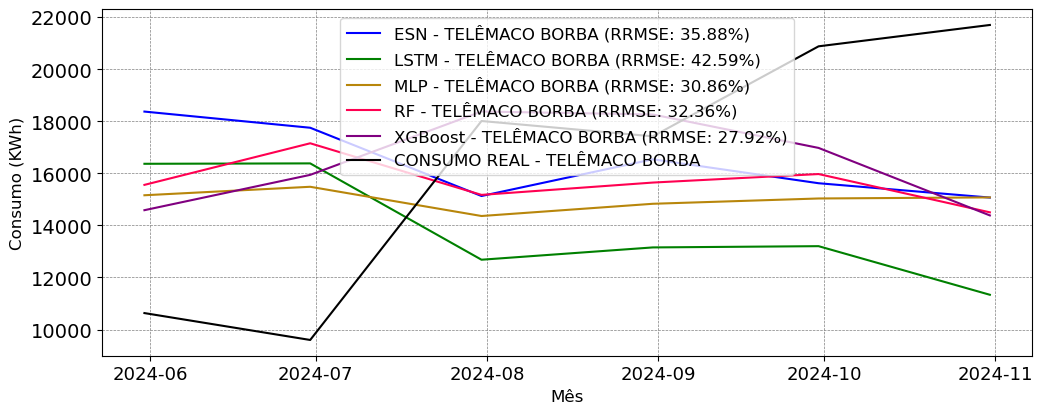

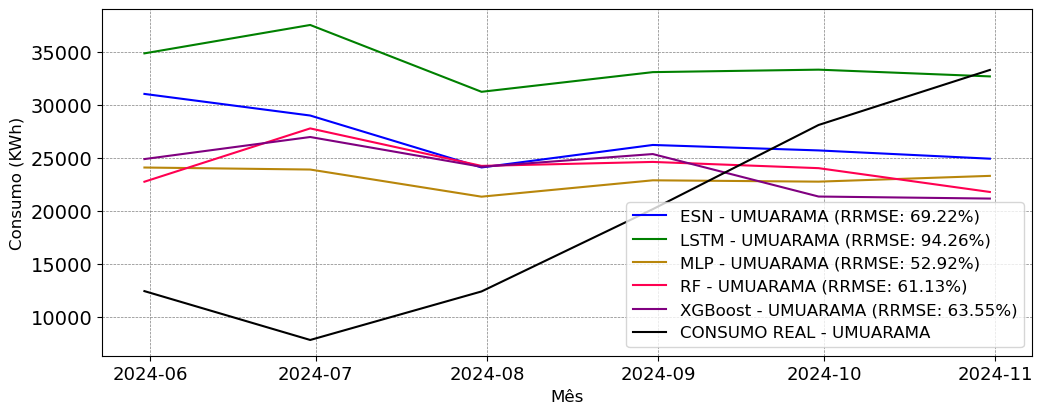

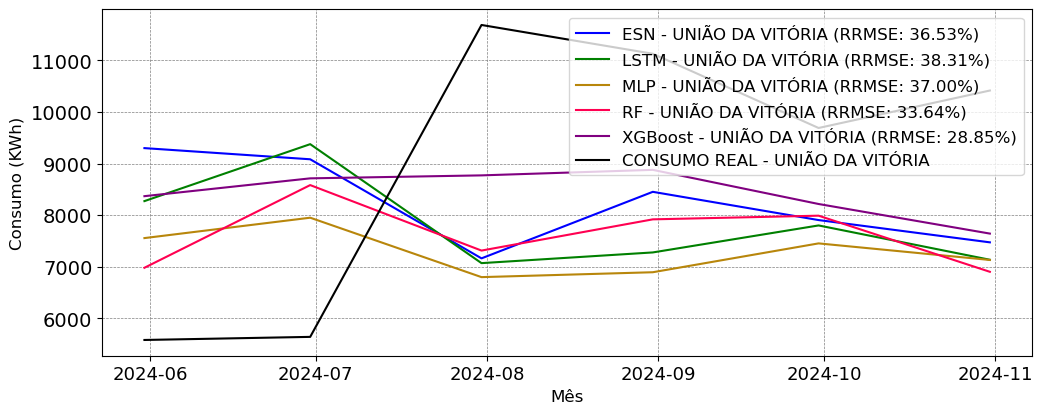

,ESN,LSTM,MLP,RF,XGBoost
ASSIS CHATEAUBRIAND,0.722258,0.795467,0.708444,0.63211,0.751639
ASTORGA,0.311863,0.580778,0.329763,0.373788,0.365088
BARRACÃO,0.260235,0.234177,0.225576,0.275592,0.251298
CAMPO LARGO,0.428984,0.66729,0.475097,0.471238,0.461105
CAPANEMA,0.557598,0.876163,0.578834,0.64312,0.673215
CASCAVEL,0.439555,0.475467,0.456794,0.471898,0.473785
CORONEL VIVIDA,0.304519,0.439335,0.29994,0.326652,0.244902
CURITIBA,0.589987,0.801305,0.537814,0.673746,0.738662
FOZ DO IGUAÇU,0.605106,0.784506,0.745909,0.669631,0.715022
GOIOERÊ,0.658971,1.248676,0.53254,0.530447,0.569955


In [3]:
df_real = pd.read_csv("./dados/dados_tratados.csv", sep=';', decimal='.')

df_RRMSE = pd.DataFrame(columns=MODELOS, index=df_real["CAMPUS"].unique())

for campus, dados in df_real.sort_values("DATA").groupby("CAMPUS"):
    try:
        consumo_previsto = pd.read_csv(f"resultados/regressão - conjunto/{HORIZONTE}M - {campus}.csv",
                                           sep=";", decimal=".", header=0)
    except Exception as e:
        continue

    consumo_previsto["DATA"] = pd.to_datetime(consumo_previsto["DATA"])
    consumo_previsto = consumo_previsto.set_index("DATA")

    dados["DATA"] = pd.to_datetime(dados["DATA"])
    dados = dados.set_index("DATA")

    df_erros = medidas_erro(dados, consumo_previsto)
    df_RRMSE.loc[campus] = df_erros["RRMSE"]

    plt = ts_comparacao(campus, dados, consumo_previsto, df_erros)

    df_erros.to_csv(f"resultados/desempenho regressão - conjunto/{HORIZONTE}M {campus}.csv",
                    sep=";", decimal=".", index=True)
    plt.savefig(f"resultados/desempenho regressão - conjunto/{HORIZONTE}M {campus}.png",
                bbox_inches='tight')
    plt.show()

df_RRMSE.loc["MÉDIA"] = df_RRMSE.mean()
df_RRMSE


## Campi individuais

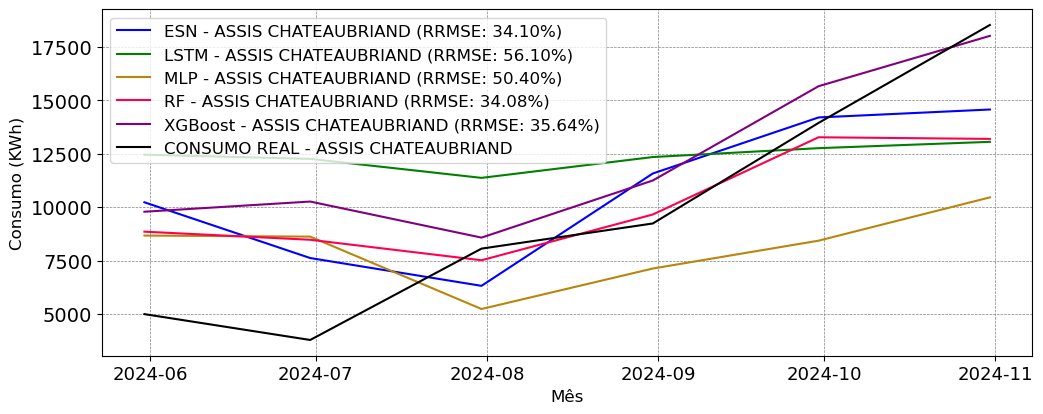

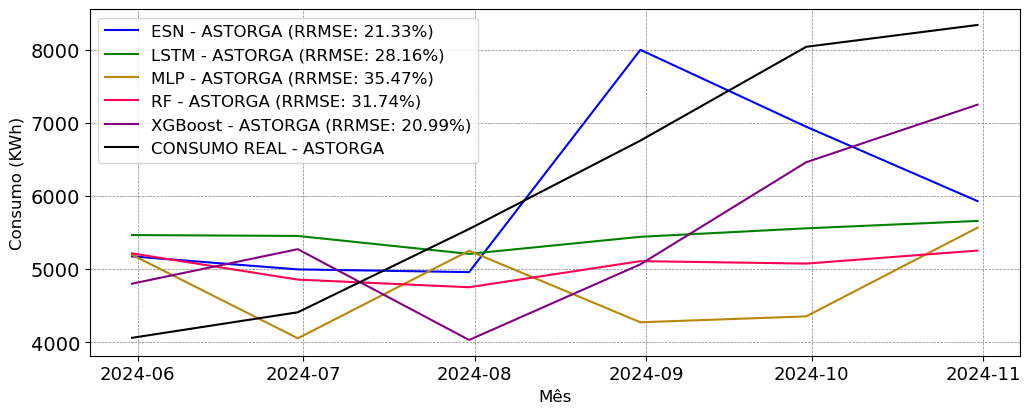

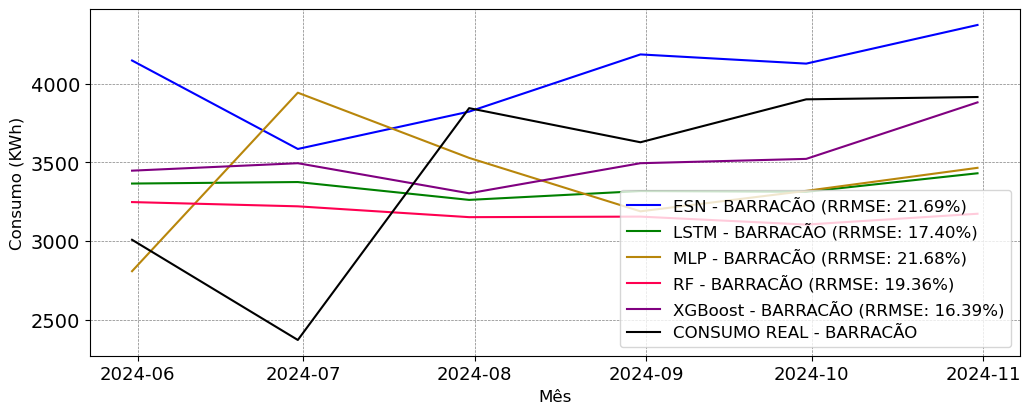

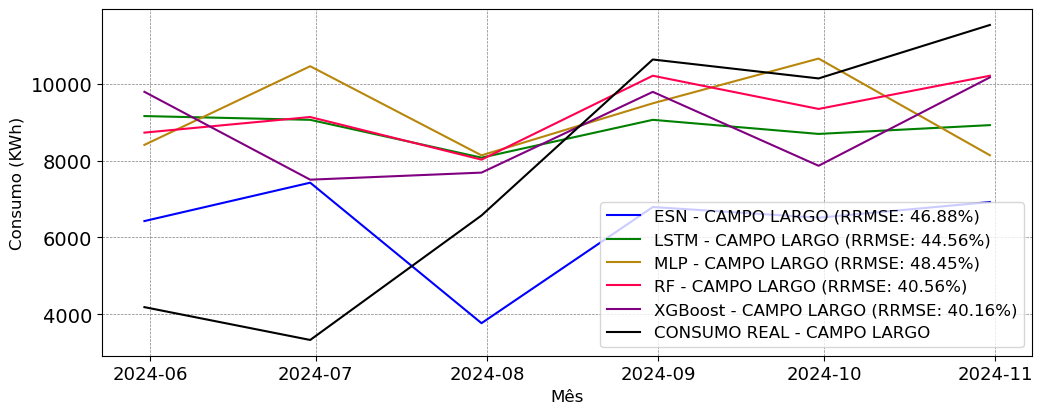

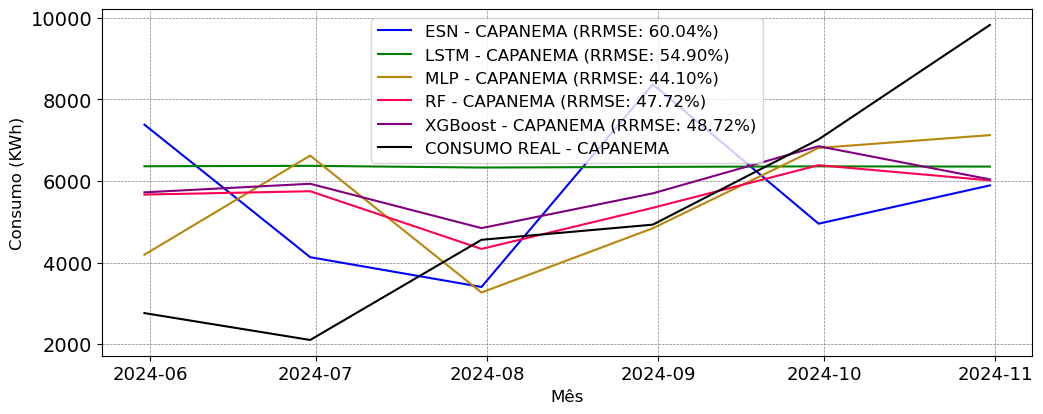

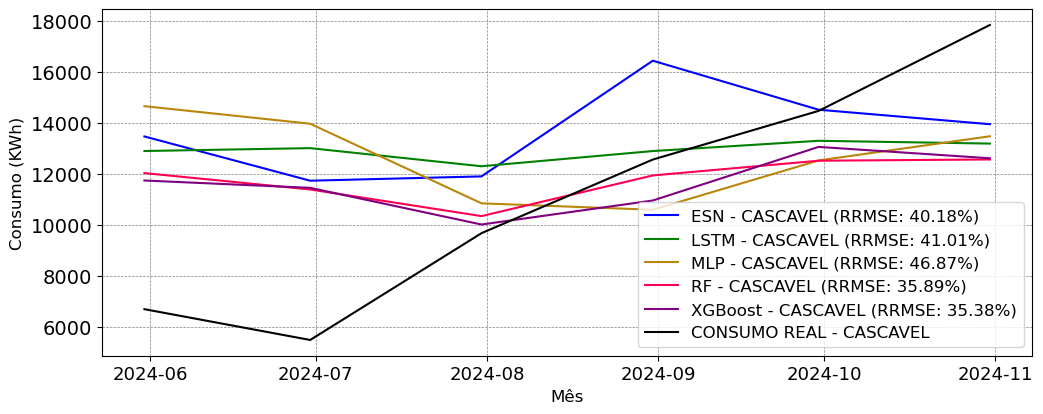

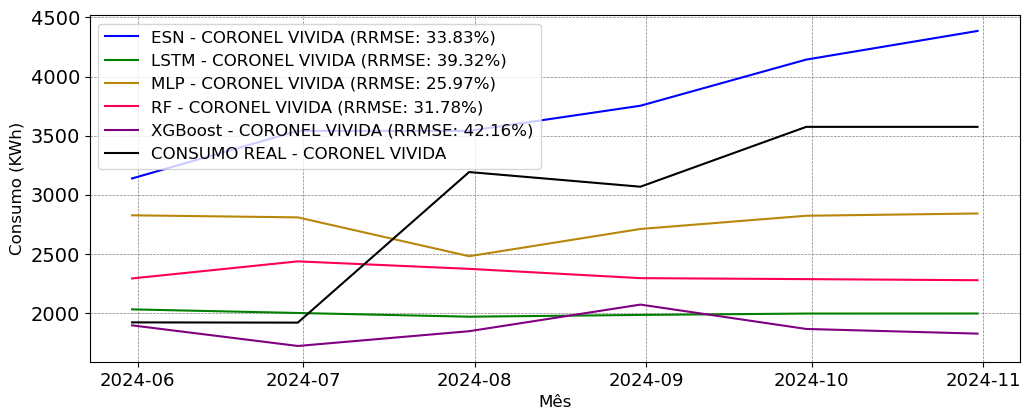

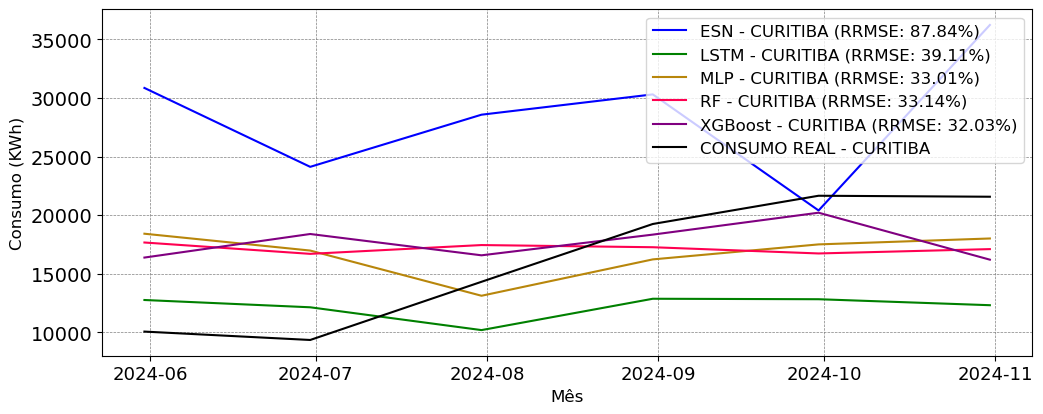

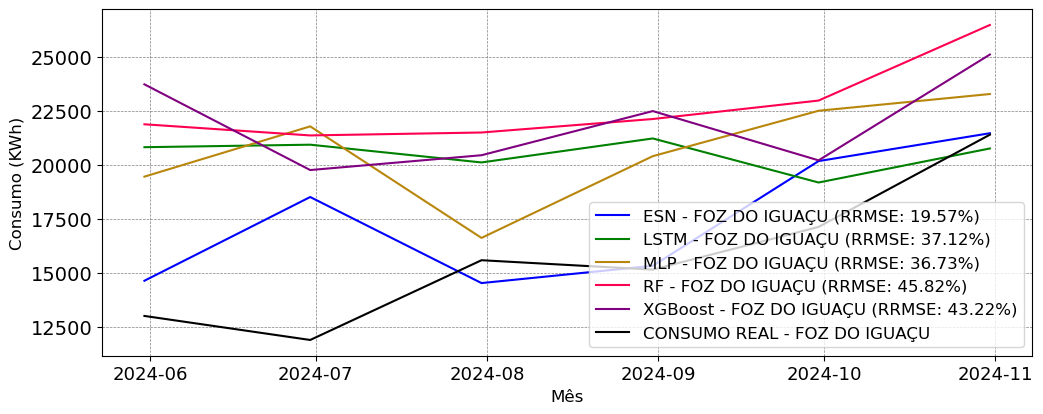

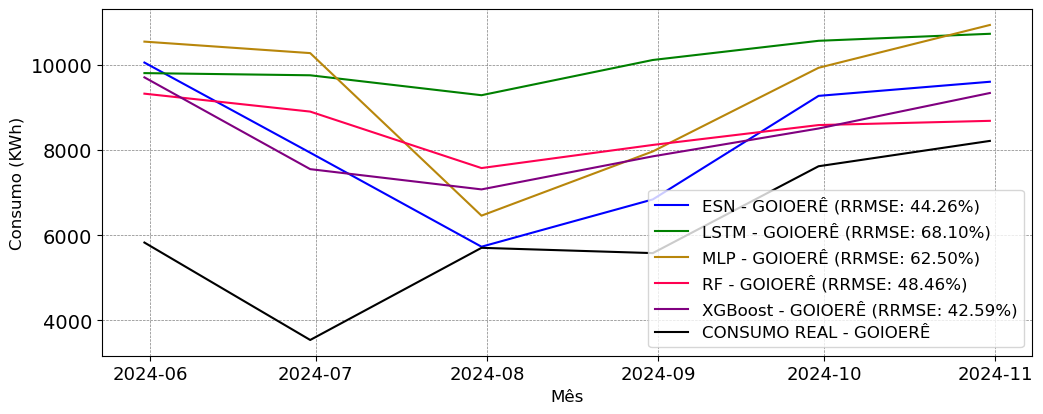

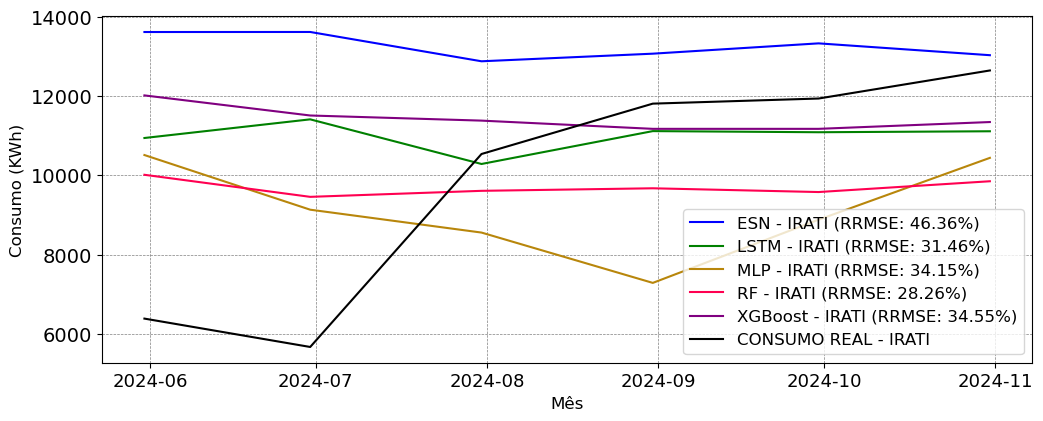

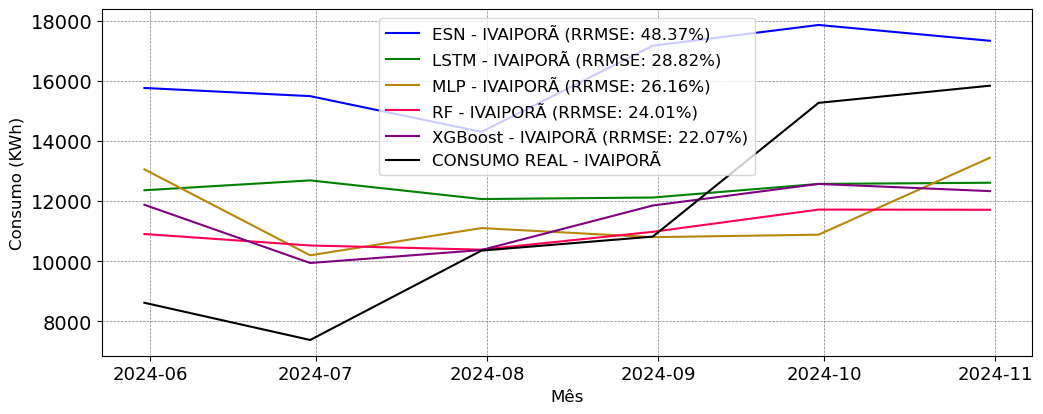

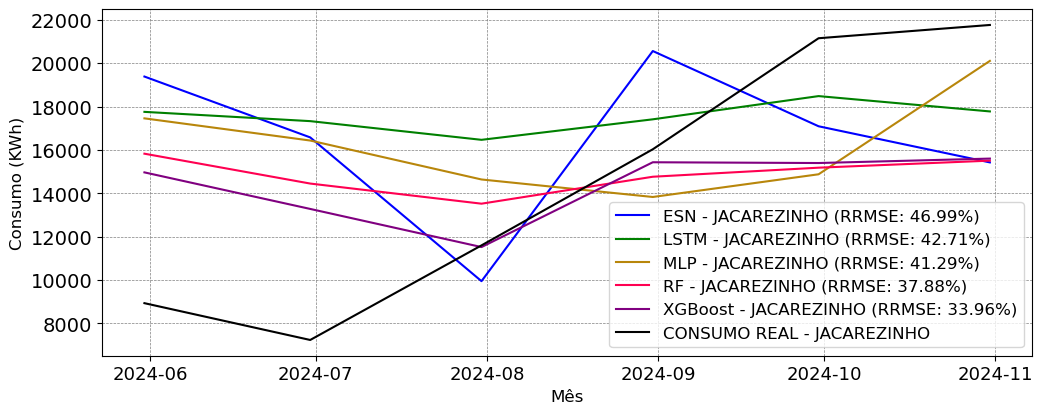

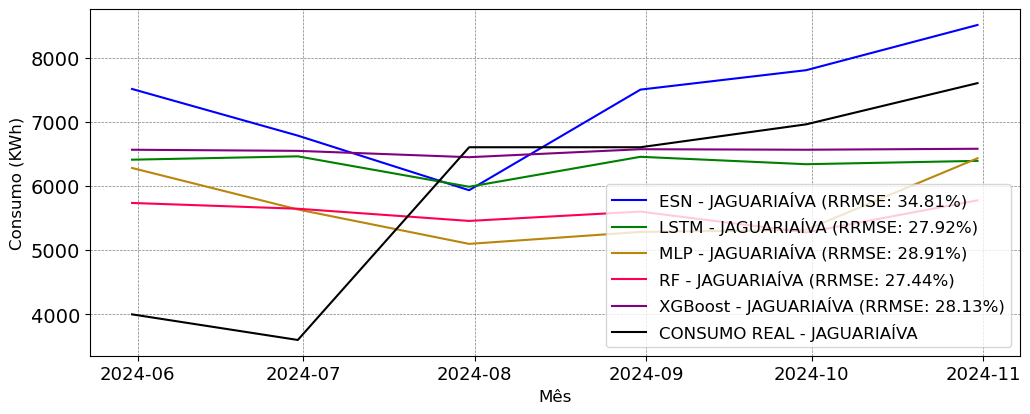

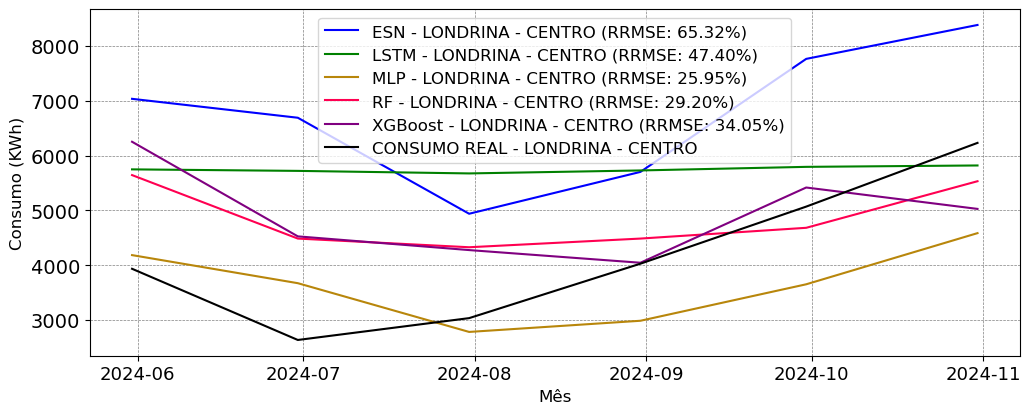

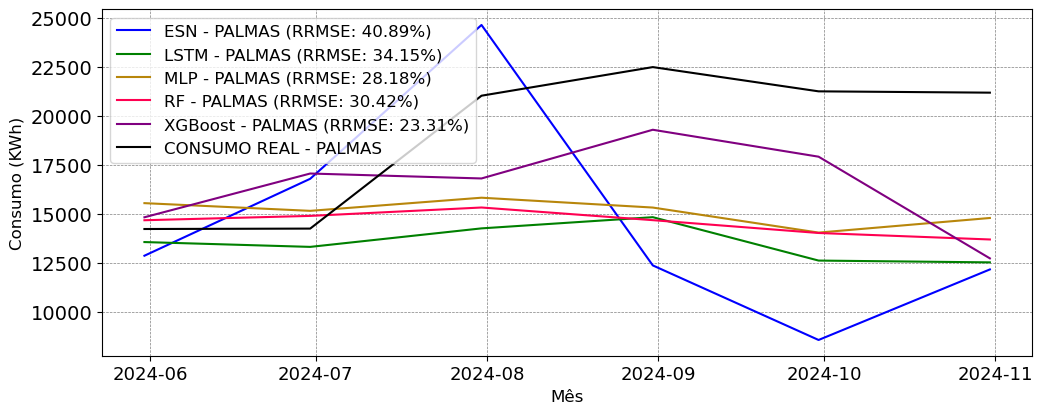

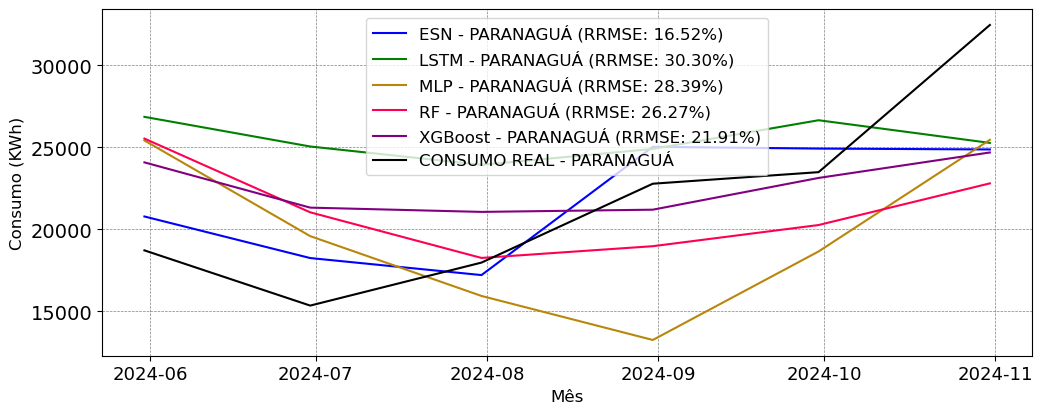

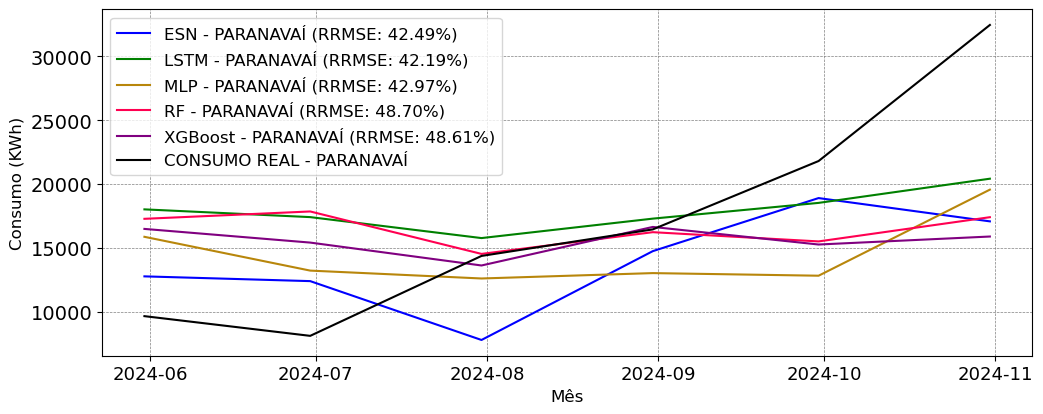

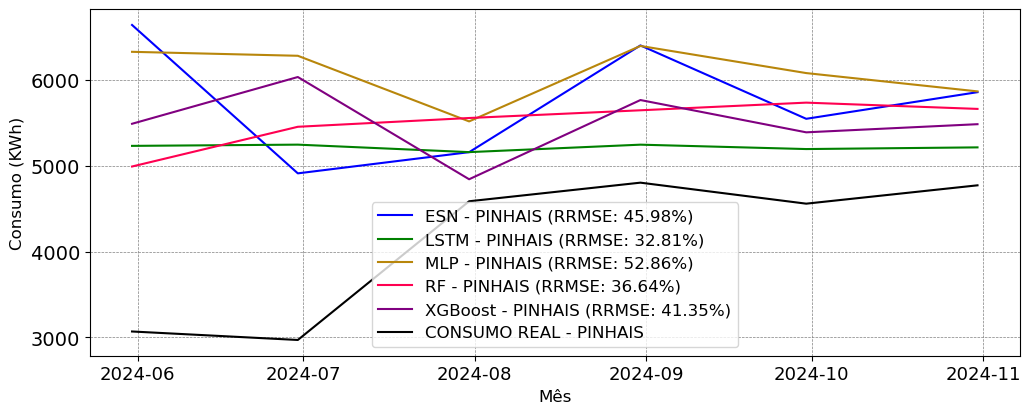

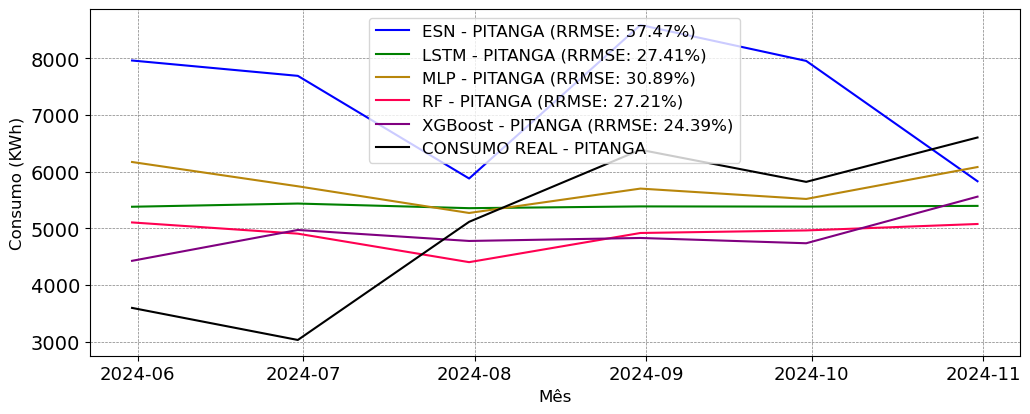

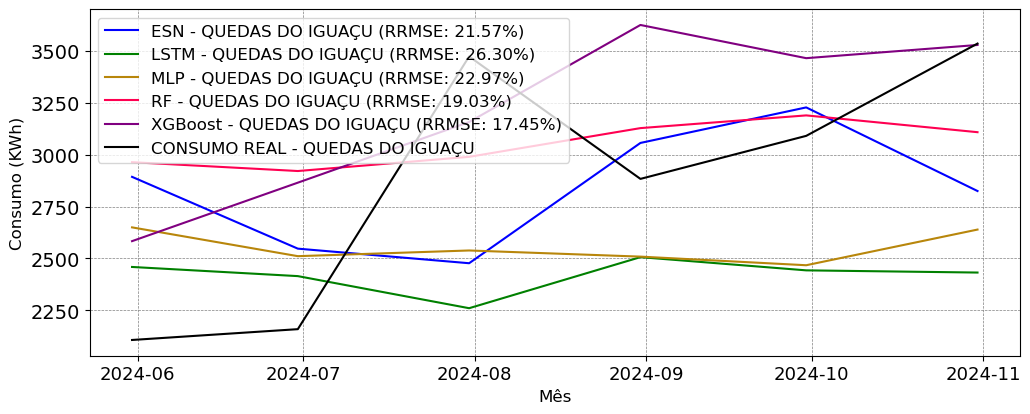

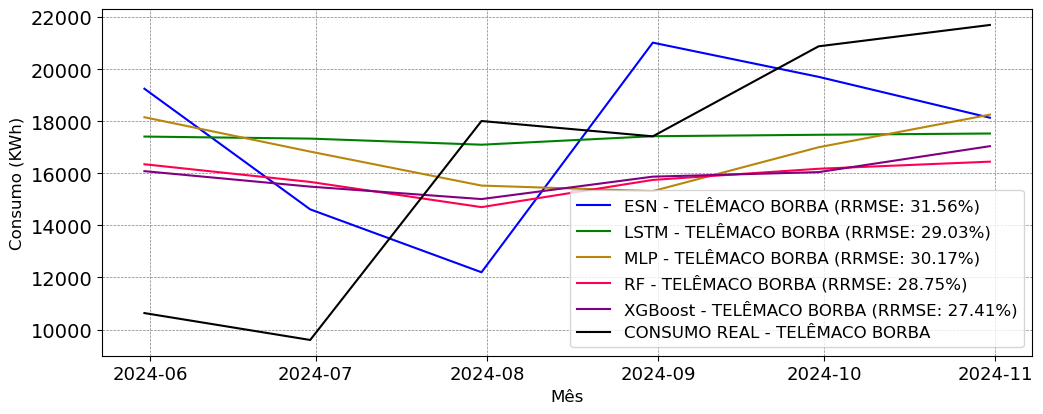

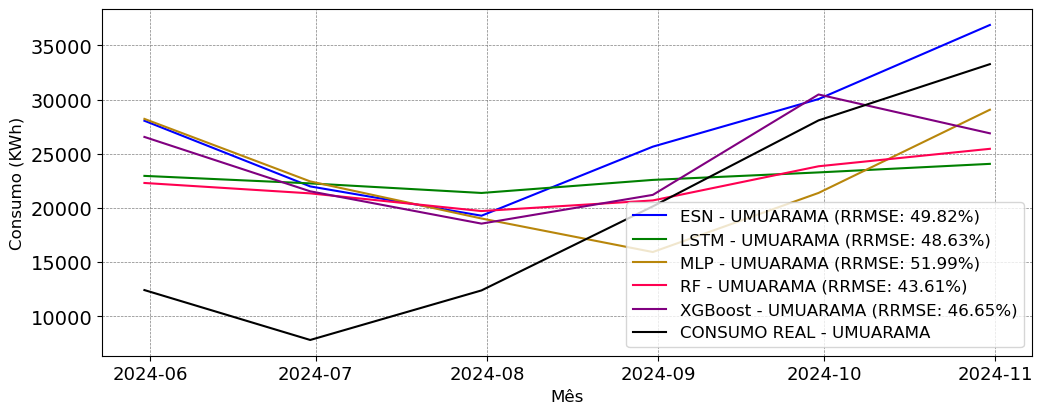

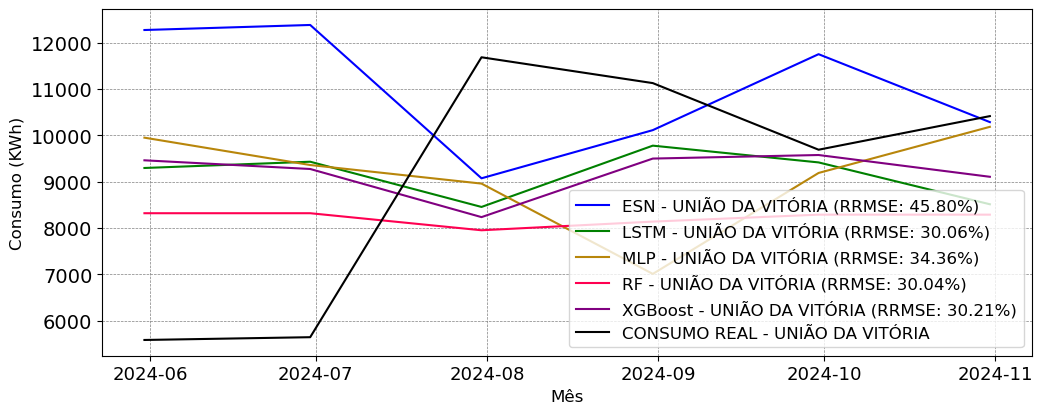

,ESN,LSTM,MLP,RF,XGBoost
ASSIS CHATEAUBRIAND,0.341012,0.560956,0.503967,0.340814,0.356443
ASTORGA,0.213256,0.281632,0.354658,0.317426,0.209908
BARRACÃO,0.216917,0.173963,0.216837,0.193646,0.163901
CAMPO LARGO,0.46877,0.445617,0.484451,0.40564,0.401572
CAPANEMA,0.60038,0.549001,0.440998,0.477158,0.487248
CASCAVEL,0.401755,0.410125,0.468708,0.358878,0.353753
CORONEL VIVIDA,0.338291,0.393181,0.259702,0.317821,0.42157
CURITIBA,0.878362,0.39107,0.330117,0.331418,0.320272
FOZ DO IGUAÇU,0.195677,0.371171,0.367306,0.458173,0.43219
GOIOERÊ,0.442588,0.68098,0.625041,0.484616,0.425879


In [4]:
df_real = pd.read_csv("./dados/dados_tratados.csv", sep=';', decimal='.')

df_RRMSE = pd.DataFrame(columns=MODELOS, index=df_real["CAMPUS"].unique())

for campus, dados in df_real.sort_values("DATA").groupby("CAMPUS"):
    try:
        consumo_previsto = pd.read_csv(f"resultados/regressão - individual/{HORIZONTE}M - {campus}.csv",
                                           sep=";", decimal=".", header=0)
    except Exception as e:
        continue

    consumo_previsto["DATA"] = pd.to_datetime(consumo_previsto["DATA"])
    consumo_previsto = consumo_previsto.set_index("DATA")

    dados["DATA"] = pd.to_datetime(dados["DATA"])
    dados = dados.set_index("DATA")

    df_erros = medidas_erro(dados, consumo_previsto)
    df_RRMSE.loc[campus] = df_erros["RRMSE"]

    plt = ts_comparacao(campus, dados, consumo_previsto, df_erros)

    df_erros.to_csv(f"resultados/desempenho regressão - individual/{HORIZONTE}M {campus}.csv",
                    sep=";", decimal=".", index=True)
    plt.savefig(f"resultados/desempenho regressão - individual/{HORIZONTE}M {campus}.png",
                bbox_inches='tight')
    plt.show()

df_RRMSE.loc["MÉDIA"] = df_RRMSE.mean()
df_RRMSE
